# ch278 — p-values

*(Directly continues ch277 — Hypothesis Testing)*

## 1. What a p-value Is

The p-value is the probability of observing a test statistic at least as extreme as the one computed, **assuming the null hypothesis is true**.

$$p = P(|T| \geq |t_{\text{obs}}| \mid H_0)$$

That is all it is. It is not:
- The probability that H₀ is true
- The probability that the result occurred by chance
- A measure of effect size
- Evidence that the result is practically important

Misreading p-values is one of the most consequential errors in applied science.

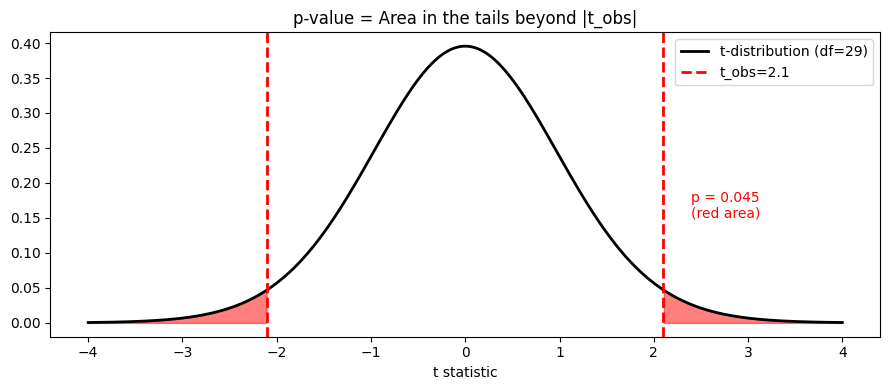

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(1)

# Demonstrate: what is the null distribution?
# Under H0, the test statistic follows a t-distribution
n  = 30
df = n - 1
t_obs = 2.1  # observed test statistic

t_range = np.linspace(-4, 4, 500)
t_pdf   = stats.t.pdf(t_range, df=df)
p_val   = 2 * stats.t.sf(abs(t_obs), df=df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_range, t_pdf, 'k-', lw=2, label=f't-distribution (df={df})')

# Shade the p-value region
for sign in [-1, 1]:
    mask = sign * t_range >= abs(t_obs)
    ax.fill_between(t_range[mask], t_pdf[mask], alpha=0.5, color='red')

ax.axvline( t_obs, color='red', lw=2, ls='--', label=f't_obs={t_obs}')
ax.axvline(-t_obs, color='red', lw=2, ls='--')
ax.text(2.4, 0.15, f'p = {p_val:.3f}\n(red area)', color='red', fontsize=10)
ax.set_title('p-value = Area in the tails beyond |t_obs|')
ax.set_xlabel('t statistic')
ax.legend()
plt.tight_layout()
plt.show()

## 2. The Calibration of p-values Under H₀

**When H₀ is true**, p-values are uniformly distributed on [0, 1]. This is not a coincidence — it follows from the definition. A p-value below 0.05 should occur 5% of the time by chance.

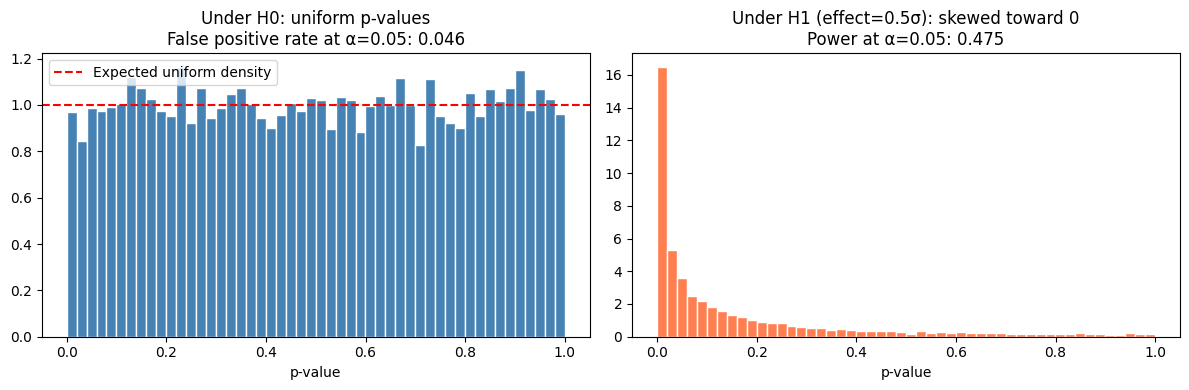

In [2]:
# Verify p-value calibration under H0
n_tests = 10_000
n_obs   = 30
pvals_null = []
pvals_alt  = []

for _ in range(n_tests):
    # Under H0: both samples from same distribution
    a = rng.normal(0, 1, n_obs)
    b = rng.normal(0, 1, n_obs)
    _, p = stats.ttest_ind(a, b)
    pvals_null.append(p)

    # Under H1: real effect
    a = rng.normal(0,   1, n_obs)
    b = rng.normal(0.5, 1, n_obs)
    _, p = stats.ttest_ind(a, b)
    pvals_alt.append(p)

pvals_null = np.array(pvals_null)
pvals_alt  = np.array(pvals_alt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pvals_null, bins=50, color='steelblue', edgecolor='white', density=True)
axes[0].axhline(1.0, color='red', ls='--', label='Expected uniform density')
axes[0].set_title(f'Under H0: uniform p-values\n'
                  f'False positive rate at α=0.05: {(pvals_null < 0.05).mean():.3f}')
axes[0].set_xlabel('p-value'); axes[0].legend()

axes[1].hist(pvals_alt, bins=50, color='coral', edgecolor='white', density=True)
axes[1].set_title(f'Under H1 (effect=0.5σ): skewed toward 0\n'
                  f'Power at α=0.05: {(pvals_alt < 0.05).mean():.3f}')
axes[1].set_xlabel('p-value')

plt.tight_layout()
plt.show()

## 3. p-hacking and Multiple Testing

If you run 20 independent tests at α = 0.05, the expected number of false positives is 1. The probability of **at least one** false positive is:

$$P(\text{at least one FP}) = 1 - (1-\alpha)^{20} = 1 - 0.95^{20} \approx 0.64$$

This is the **multiple comparisons problem**. It is solved by adjusting the significance threshold.

In [3]:
# Bonferroni correction
def bonferroni_correction(pvals: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    """Reject H0 only if p < alpha/m."""
    m = len(pvals)
    return pvals < (alpha / m)

# Benjamini-Hochberg FDR correction
def bh_correction(pvals: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    """
    Benjamini-Hochberg procedure: controls False Discovery Rate at level alpha.
    Returns boolean mask of rejections.
    """
    m    = len(pvals)
    rank = np.argsort(pvals)
    sorted_p = pvals[rank]
    thresholds = (np.arange(1, m+1) / m) * alpha
    # Largest k such that p_(k) <= k*alpha/m
    below = sorted_p <= thresholds
    if not below.any():
        return np.zeros(m, dtype=bool)
    k_max = np.where(below)[0].max()
    reject_sorted = np.zeros(m, dtype=bool)
    reject_sorted[:k_max+1] = True
    reject = np.zeros(m, dtype=bool)
    reject[rank] = reject_sorted
    return reject

# Simulate 100 tests, 10% truly have an effect
m     = 100
m_alt = 10
pvals = np.concatenate([
    stats.ttest_ind(
        rng.normal(0, 1, 50), rng.normal(0.8, 1, 50)
    ).pvalue * np.ones(1) for _ in range(m_alt)
] + [
    stats.ttest_ind(
        rng.normal(0, 1, 50), rng.normal(0, 1, 50)
    ).pvalue * np.ones(1) for _ in range(m - m_alt)
])
# Flatten
pvals = pvals.ravel()
truth = np.array([True]*m_alt + [False]*(m-m_alt))

reject_naive     = pvals < 0.05
reject_bonf      = bonferroni_correction(pvals)
reject_bh        = bh_correction(pvals)

for name, rej in [
    ('Naive (α=0.05)',  reject_naive),
    ('Bonferroni',      reject_bonf),
    ('B-H (FDR=0.05)', reject_bh),
]:
    fp = (rej & ~truth).sum()
    tp = (rej &  truth).sum()
    print(f"{name:<20}: {rej.sum():3d} rejected, TP={tp}, FP={fp}")

Naive (α=0.05)      :  17 rejected, TP=10, FP=7
Bonferroni          :   8 rejected, TP=8, FP=0
B-H (FDR=0.05)      :  12 rejected, TP=10, FP=2


## 4. Effect Size: What p Cannot Tell You

In [4]:
# Tiny effect, huge sample = tiny p-value
# Large effect, tiny sample = large p-value
cases = [
    {'n': 10,    'effect': 5.0,  'sigma': 10.0},
    {'n': 100,   'effect': 5.0,  'sigma': 10.0},
    {'n': 10000, 'effect': 0.1,  'sigma': 10.0},  # tiny effect, massive sample
    {'n': 10,    'effect': 15.0, 'sigma': 10.0},
]

print(f"{'n':>6}  {'effect':>8}  {'Cohen d':>8}  {'p-value':>10}  {'Interpretation'}")
print("-" * 70)
for c in cases:
    a = rng.normal(0,          c['sigma'], c['n'])
    b = rng.normal(c['effect'], c['sigma'], c['n'])
    _, p = stats.ttest_ind(a, b)
    d = c['effect'] / c['sigma']  # Cohen's d
    interp = 'small' if d < 0.2 else 'medium' if d < 0.8 else 'large'
    print(f"{c['n']:>6}  {c['effect']:>8.1f}  {d:>8.2f}  {p:>10.6f}  Effect size: {interp}")

     n    effect   Cohen d     p-value  Interpretation
----------------------------------------------------------------------
    10       5.0      0.50    0.445114  Effect size: medium
   100       5.0      0.50    0.049328  Effect size: medium
 10000       0.1      0.01    0.307902  Effect size: small
    10      15.0      1.50    0.131925  Effect size: large


## 5. What Comes Next

**ch279 — Confidence Intervals** reframes the same test in a more informative way: instead of asking "is the effect zero?", it estimates the plausible range of the effect size. This is almost always more useful for decision-making.

The multiple testing correction (Benjamini-Hochberg) will reappear in **ch285 — A/B Testing** where running many simultaneous experiments is the norm.